In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import pathlib
import gc
import warnings
warnings.filterwarnings('ignore')

import itertools
from sklearn import metrics

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

ROOT = pathlib.Path().resolve()
DATA_FOLDER = ROOT / "data/bike"

print(DATA_FOLDER)

C:\Users\PatCa\Documents\PythonScripts\test_projects\big_data\bike_data\data\bike


In [3]:
df = pd.read_parquet('all_years_weekly.parquet')

print(df.shape)
print(df.dtypes)
display(df.head(4))

(314, 2)
count_trips           int64
start_tripduration    int32
dtype: object


,count_trips,start_tripduration
starttime,,
2014-01-05,19855,16052099
2014-01-12,66987,45280072
2014-01-19,107472,74364131
2014-01-26,39418,30976679


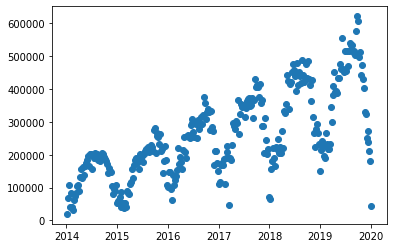

In [4]:
plt.figure()
plt.scatter(df.index, df.count_trips)
plt.show()

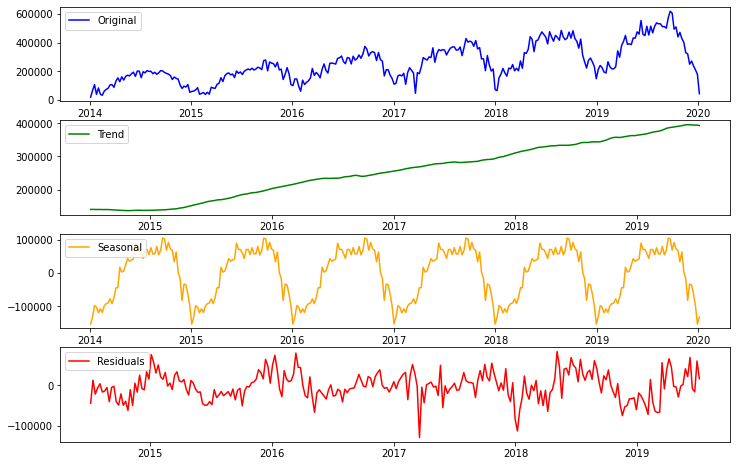

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose


decomposition = seasonal_decompose(df['count_trips'])

def decomp(decomposition, df):
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residuals = decomposition.resid

    plt.figure(figsize=(12,8))
    plt.subplot(411)
    plt.plot(df['count_trips'],label='Original',color='blue')
    plt.legend(loc='upper left')
    plt.subplot(412)
    plt.plot(trend,label='Trend',color='green')
    plt.legend(loc='upper left')
    plt.subplot(413)
    plt.plot(seasonal,label='Seasonal',color='orange')
    plt.legend(loc='upper left')
    plt.subplot(414)
    plt.plot(residuals,label='Residuals',color='red')
    plt.legend(loc='upper left')
    
decomp(decomposition, df)

In [6]:
# Log data
df['log_trips'] = df['count_trips'].apply(lambda x: np.log(x))

# Make stationary
df['log_trips_shift'] = df['log_trips'].diff()
display(df.head(4))

,count_trips,start_tripduration,log_trips,log_trips_shift
starttime,,,,
2014-01-05,19855,16052099,9.896211,NaN
2014-01-12,66987,45280072,11.112254,1.216043
2014-01-19,107472,74364131,11.584986,0.472732
2014-01-26,39418,30976679,10.581978,-1.003008


In [7]:
# Make train test
df1 = df.dropna()
train_len = int(df1.shape[0] * 0.9)

train = df1.iloc[:train_len,:]
test = df1.iloc[train_len:,:]
print(train.shape, test.shape)

(281, 4) (32, 4)


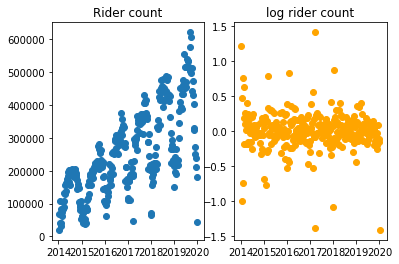

In [8]:
plt.figure()
plt.subplot(1,2,1)
plt.scatter(df.index, df.count_trips)
plt.title("Rider count")
plt.subplot(1,2,2)
plt.scatter(df.index, df['log_trips_shift'], color='orange')
plt.title('log rider count')
plt.tight_layout
plt.show()

In [9]:
# Reverse transform data columns.
df['reversed2'] = np.exp(df.loc['2014-01-05', 'log_trips'] + df['log_trips_shift'].cumsum())
display(df.head(4))


,count_trips,start_tripduration,log_trips,log_trips_shift,reversed2
starttime,,,,,
2014-01-05,19855,16052099,9.896211,NaN,NaN
2014-01-12,66987,45280072,11.112254,1.216043,66987.0
2014-01-19,107472,74364131,11.584986,0.472732,107472.0
2014-01-26,39418,30976679,10.581978,-1.003008,39418.0


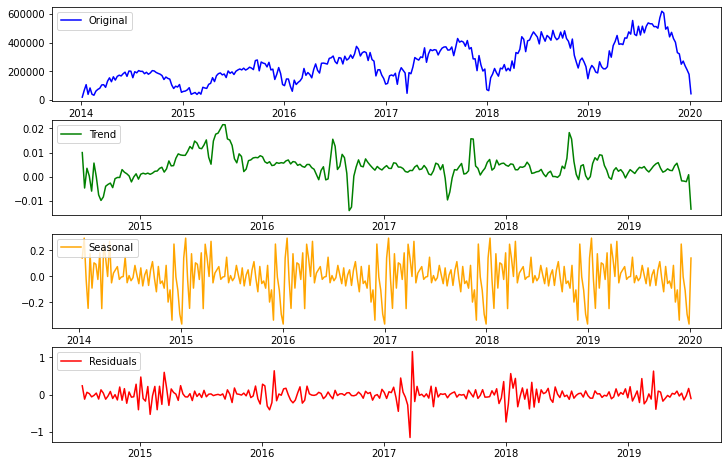

In [10]:
decomposition = seasonal_decompose(df['log_trips_shift'].dropna())
decomp(decomposition, df)

# Optimize SARIMAX and check best fit

In [11]:

# Create tuples of every p, d, q combination for 0 and 1
# Note: code below takes ~30 minutes to run

p = q = range(0, 2)
pdq = list(itertools.product(p, [1], q))
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, [1], q))]

# Set initial EV to some initially low amount
best_ev = 0

for param in pdq:
    for param_seasonal in seasonal_pdq: 
        mod = SARIMAX(train['log_trips_shift'], order=param, seasonal_order=param_seasonal).fit(maxiter=1000, disp=False)
        
        forecast = mod.forecast(steps = len(test['log_trips_shift'])).to_frame()
        forecast['renorm'] = np.exp(train.iloc[-1, 2] + forecast.iloc[:,0].cumsum())
        # Note: I want the model that maximizes explained variance on the actual ridership data
        # The tradeoff is very slightly worse performance on log transformed data in return
        # for substantial improvements on actual ridership data
        ev = metrics.explained_variance_score((test['count_trips']), forecast['renorm'])
        print(ev)
        
        if ev > best_ev:
            best_ev = ev
            best_order = param
            best_s_order = param_seasonal

c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'
c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'


-0.02385158042924118


c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'
c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'


-210.23074206411607


c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'
c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'


...

0.8509943794299162


c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'
c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'


0.8468709901586051


c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'
c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'


0.842117557063672


In [12]:
print(best_order, best_s_order)

(1, 1, 1) (0, 1, 1, 52)


In [13]:
# First seasonal model without grid searching, using 52 weeks lag
seas_mod_weekly = SARIMAX(train['log_trips_shift'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 52)).fit()
seas_mod_weekly.summary()

c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'
c:\Users\PatCa\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  warnings.warn('No frequency information was'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    log_trips_shift   No. Observations:                  281
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 52)   Log Likelihood                 -37.415
Date:                            Mon, 21 Nov 2022   AIC                             82.830
Time:                                    14:49:38   BIC                             96.547
Sample:                                01-12-2014   HQIC                            88.364
                                     - 05-26-2019                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4388      0.041    -10.783      0.000      -0.518      -0.359
ma.L1         -0.9984      0.545     -1.831      0.067      -2.067       0.070
ma.S.L52      -0.9445      0.473     -1.999      0.046      -1.871      -0.018
sigma2         0.0564      0.039      1.443      0.149      -0.020       0.133
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):               601.10
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               0.73   Skew:                            -0.08
Prob(H) (two-sided):                  0.18   Kurtosis:                        10.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

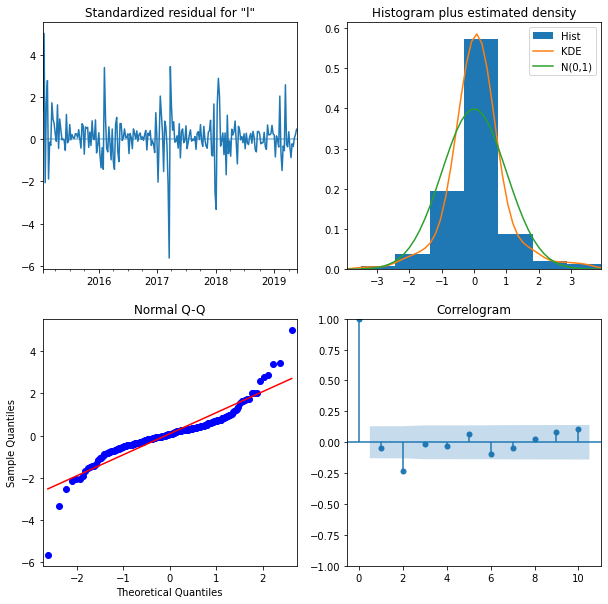

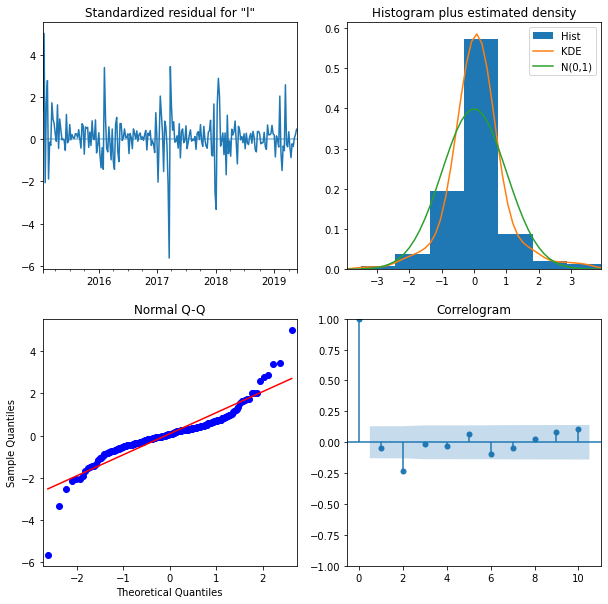

In [14]:
seas_mod_weekly.plot_diagnostics(figsize = (10,10))

In [15]:
from sklearn import metrics
model_forecast = seas_mod_weekly.forecast(steps = test.shape[0]).to_frame()
#print(type(model_forecast))

model_forecast['renorm'] = np.exp(train.iloc[-1, 2] + model_forecast.iloc[:,0].cumsum())

ev = metrics.explained_variance_score((test['count_trips']), model_forecast['renorm'])
mape_ = metrics.mean_absolute_percentage_error((test['count_trips']), model_forecast['renorm'])
mae_ = metrics.mean_absolute_error((test['count_trips']), model_forecast['renorm'])
rms = np.sqrt(metrics.mean_squared_error((test['count_trips']), model_forecast['renorm']))

print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')

explained variance: 0.85, mape: 0.19, mae: 40929.27, rms: 51914.56


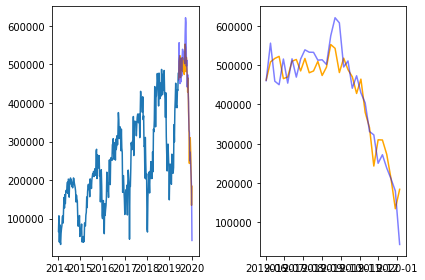

In [40]:
plt.figure()
plt.subplot(1,2,1)
plt.plot(train.index, train.count_trips)
plt.plot(model_forecast.index, model_forecast['renorm'], color='orange')
plt.plot(test.index, test.count_trips, color='blue', alpha=0.5)

plt.subplot(1,2,2)
plt.plot(model_forecast.index, model_forecast['renorm'], color='orange')
plt.plot(test.index, test.count_trips, color='blue', alpha=0.5)
plt.tight_layout()
plt.show()



# LSTM

In [17]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional, \
                        Conv1D, Flatten,MaxPooling1D, ConvLSTM2D, \
                        TimeDistributed, RepeatVector, Bidirectional, GRU
from keras.optimizers import Adam

In [18]:
# Format data for supervised learning problem
print(train.shape, test.shape)
display(train.head(5))

(281, 4) (32, 4)


,count_trips,start_tripduration,log_trips,log_trips_shift
starttime,,,,
2014-01-12,66987,45280072,11.112254,1.216043
2014-01-19,107472,74364131,11.584986,0.472732
2014-01-26,39418,30976679,10.581978,-1.003008
2014-02-02,84278,60393006,11.341876,0.759898
2014-02-09,40244,38013273,10.602716,-0.739160


In [19]:
# Multi output step LSTM model
# Input is numpy arrays output is X[samples, in_step], y[samples]
def seq_multi_LSTM(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    X = np.array(X)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, np.array(y)


def print_curves(history, train_met, test_met):
    plt.figure()
    plt.plot(history.history[train_met], label='train')
    plt.plot(history.history[test_met], label='test')
    plt.title(train_met)
    plt.legend()
    plt.show()
    return


def lstm_model(Xtrain, n_output, n1=100, n2=50, d_out=0.0):
    model = Sequential()
    model.add(LSTM(n1, activation='relu', return_sequences=True, input_shape=(Xtrain.shape[1], Xtrain.shape[2]), dropout=d_out))
    model.add(LSTM(n2, activation='relu', dropout=d_out))
    model.add(Dense(n_output))
    model.compile(optimizer='adam', loss='mse', metrics='mae')
    return model

def gru_model(Xtrain, n_output, n1=100, n2=50, d_out=0.0):
    model = Sequential()
    model.add(GRU(n1, activation='relu', return_sequences=True, input_shape=(Xtrain.shape[1], Xtrain.shape[2]), dropout=d_out))
    model.add(GRU(n2, activation='relu', dropout=d_out))
    model.add(Dense(2*n_output, activation='relu'))
    model.add(Dense(n_output))
    model.compile(optimizer='adam', loss='mse', metrics='mae')
    return model


def pred_check(y_pred):
    ev = metrics.explained_variance_score((test['count_trips']), y_pred)
    mape_ = metrics.mean_absolute_percentage_error((test['count_trips']), y_pred)
    mae_ = metrics.mean_absolute_error((test['count_trips']), y_pred)
    rms = np.sqrt(metrics.mean_squared_error((test['count_trips']), y_pred))

    print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')

    plt.figure()
    plt.plot(train.index, train.iloc[:,0])
    plt.plot(test.index, y_pred, color='orange')
    plt.plot(test.index, test.iloc[:,0], color='purple', alpha=0.2)
    plt.show()
    return
    
    

## LSTM one-period walk-forward prediction test

In [20]:
n_input = 12
n_output = 1

Xtrain, ytrain = seq_multi_LSTM(train['log_trips_shift'], n_input, n_output)
Xtest, ytest = seq_multi_LSTM(test['log_trips_shift'], n_input, n_output)

print(Xtrain.shape, ytrain.shape)
print(Xtest.shape, ytest.shape)

(269, 12, 1) (269, 1)
(20, 12, 1) (20, 1)


In [21]:
#-------------------------- Basic multi step output LSTM -----------------------------------------------------
model = lstm_model(Xtrain, n_output, n1=25, n2=25, d_out=0.2)


Epoch 1/100
5/5 [==============================] - 18s 1s/step - loss: 0.0612 - mae: 0.1602 - val_loss: 0.1163 - val_mae: 0.1685
Epoch 2/100
5/5 [==============================] - 4s 781ms/step - loss: 0.0611 - mae: 0.1605 - val_loss: 0.1177 - val_mae: 0.1712
Epoch 3/100
5/5 [==============================] - 4s 772ms/step - loss: 0.0609 - mae: 0.1604 - val_loss: 0.1182 - val_mae: 0.1720
Epoch 4/100
5/5 [==============================] - 4s 777ms/step - loss: 0.0608 - mae: 0.1600 - val_loss: 0.1161 - val_mae: 0.1679
Epoch 5/100
5/5 [==============================] - 4s 763ms/step - loss: 0.0605 - mae: 0.1595 - val_loss: 0.1145 - val_mae: 0.1650
Epoch 6/100
5/5 [==============================] - 4s 790ms/step - loss: 0.0605 - mae: 0.1595 - val_loss: 0.1131 - val_mae: 0.1626
Epoch 7/100
5/5 [==============================] - 4s 777ms/step - loss: 0.0607 - mae: 0.1595 - val_loss: 0.1126 - val_mae: 0.1618
Epoch 8/100
5/5 [==============================] - 4s 786ms/step - loss: 0.0604 - mae

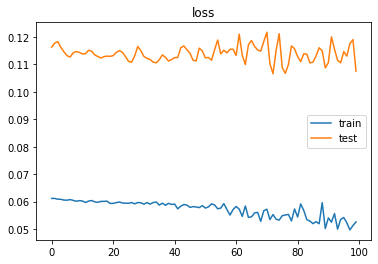

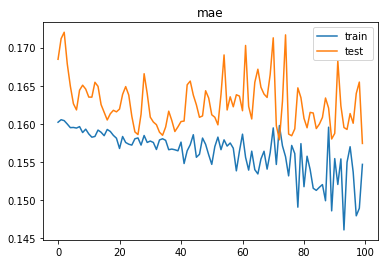

In [22]:
history = model.fit(Xtrain, ytrain, batch_size=64, epochs=100,
                    validation_data=(Xtest, ytest), verbose=1)

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

In [23]:
# Predict test data
Xtest_all = np.concatenate((Xtrain[-12:,:,:], Xtest), axis=0)
ytest_all = test['log_trips_shift'].to_numpy()
ytest_all = ytest_all[:, np.newaxis]

print(Xtest_all.shape, ytest_all.shape)

(32, 12, 1) (32, 1)


1/1 [==============================] - 2s 2s/step
explained variance: 0.15, mape: 0.58, mae: 251811.40, rms: 278774.77


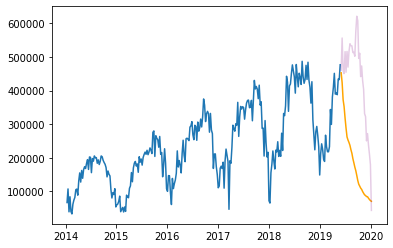

In [24]:
y_pred = model.predict(Xtest_all)
y_pred_detrans = np.exp(train.iloc[-1,2] + y_pred[:,0].cumsum())

pred_check(y_pred_detrans)

In [25]:
print(y_pred)

[[-0.05093002]
 [-0.06836808]
 [-0.12698574]
 [-0.05567005]
 [-0.10210889]
 [-0.09887755]
 [-0.094823  ]
 [-0.03589665]
 [-0.02892087]
 [-0.03581563]
 [-0.05595692]
 [-0.04897903]
 [-0.07674663]
 [-0.06414466]
 [-0.07279142]
 [-0.06408433]
 [-0.09076373]
 [-0.10552081]
 [-0.0881652 ]
 [-0.04794183]
 [-0.05315726]
 [-0.03500547]
 [-0.06231305]
 [-0.05199888]
 [-0.05151752]
 [-0.02244   ]
 [-0.03818241]
 [-0.00337331]
 [-0.05476714]
 [-0.0495308 ]
 [-0.04297464]
 [-0.02836269]]


## Multi output LSTM

In [41]:
n_input = 12
n_output = 16

Xtrain, ytrain = seq_multi_LSTM(train['log_trips_shift'], n_input, n_output)
Xtest, ytest = seq_multi_LSTM(test['log_trips_shift'], n_input, n_output)

print(Xtrain.shape, ytrain.shape)
print(Xtest.shape, ytest.shape)


(254, 12, 1) (254, 16)
(5, 12, 1) (5, 16)


In [42]:
#-------------------------- Basic LSTM -----------------------------------------------------
#model = lstm_model(Xtrain, n_output, n1=25, n2=25, d_out=0.0)
model = gru_model(Xtrain, n_output, n1=100, n2=100, d_out=0.2)

Epoch 1/10
8/8 [==============================] - 2s 293ms/step - loss: 0.0625 - mae: 0.1615 - val_loss: 0.0402 - val_mae: 0.1201
Epoch 2/10
8/8 [==============================] - 2s 306ms/step - loss: 0.0624 - mae: 0.1612 - val_loss: 0.0401 - val_mae: 0.1196
Epoch 3/10
8/8 [==============================] - 2s 301ms/step - loss: 0.0624 - mae: 0.1615 - val_loss: 0.0396 - val_mae: 0.1183
Epoch 4/10
8/8 [==============================] - 2s 299ms/step - loss: 0.0623 - mae: 0.1614 - val_loss: 0.0396 - val_mae: 0.1182
Epoch 5/10
8/8 [==============================] - 2s 302ms/step - loss: 0.0623 - mae: 0.1614 - val_loss: 0.0392 - val_mae: 0.1171
Epoch 6/10
8/8 [==============================] - 2s 289ms/step - loss: 0.0621 - mae: 0.1609 - val_loss: 0.0390 - val_mae: 0.1169
Epoch 7/10
8/8 [==============================] - 3s 318ms/step - loss: 0.0620 - mae: 0.1608 - val_loss: 0.0390 - val_mae: 0.1170
Epoch 8/10
8/8 [==============================] - 2s 312ms/step - loss: 0.0620 - mae: 0.16

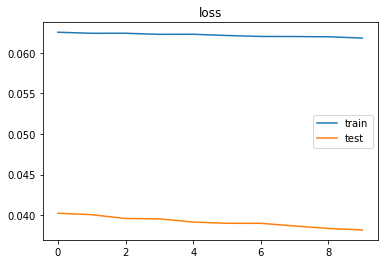

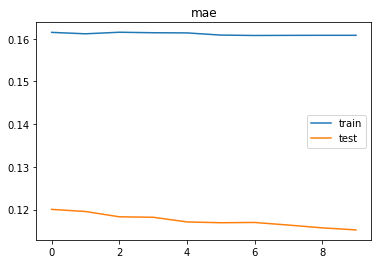

In [44]:
history = model.fit(Xtrain, ytrain, batch_size=32, epochs=10,
                    validation_data=(Xtest, ytest), verbose=1)

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

In [45]:
# 12 in 16 out...
n_totput = n_input + n_output

pred_data = test[['log_trips_shift']].iloc[-n_totput:,:]
pred_X = pred_data.iloc[-n_totput:-n_output,:].to_numpy().reshape(1,n_input,1)
pred_y = pred_data.iloc[-n_output:,:].to_numpy().reshape(n_output,1)

print(pred_X.shape, pred_y.shape)


(1, 12, 1) (16, 1)


In [46]:
def plot_multi(y_pred):
    pred_time = y_pred_detrans.shape[0]
    
    ev = metrics.explained_variance_score(test.iloc[-pred_time:,0], y_pred)
    mape_ = metrics.mean_absolute_percentage_error(test.iloc[-pred_time:,0], y_pred)
    mae_ = metrics.mean_absolute_error(test.iloc[-pred_time:,0], y_pred)
    rms = np.sqrt(metrics.mean_squared_error(test.iloc[-pred_time:,0], y_pred))

    print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')
    
    plt.figure()
    plt.plot(train.index, train['count_trips'])
    plt.plot(test.index, test['count_trips'], color='purple', alpha=0.2)
    plt.plot(test.iloc[-pred_time:,:].index, y_pred)
    plt.show()
    
    return

1/1 [==============================] - 0s 363ms/step
[444508.94 435935.9  416566.8  412425.38 403520.22 379838.97 355525.1
 331239.84 315007.22 288886.62 267563.78 249289.61 239953.34 223657.7
 206430.2  192311.92]
explained variance: 0.76, mape: 0.34, mae: 67712.52, rms: 87558.66


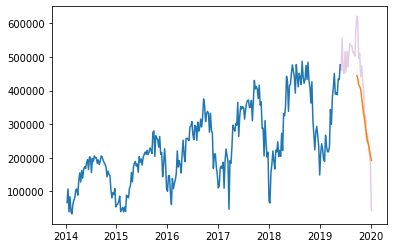

In [31]:
y_pred = model.predict(pred_X)
y_pred = y_pred.reshape(n_output,1)

y_pred_detrans = np.exp(test.iloc[-(n_totput+1),2] + y_pred[:,0].cumsum())
print(y_pred_detrans)

plot_multi(y_pred_detrans)



## Func LSTM
Use input and output size to split the data in train, test and predict sets

In [32]:
# Use input and output to split the data 
# Choose input and output
n_input = 12
n_output = 16

# Choose val and predict size
# Val is 2xn_output, predict test is 1xn_output
test_size = int(n_output * 3)

# Slice dataframe
lstm_train = df.iloc[1:-test_size,:]
lstm_test = df.iloc[-(test_size+n_input):-(n_output),:]
lstm_predict = df.iloc[-(n_output+n_input):,:]['log_trips_shift']

# Make train and test set
Xtrain, ytrain = seq_multi_LSTM(lstm_train['log_trips_shift'], n_input, n_output)
Xtest, ytest = seq_multi_LSTM(lstm_test['log_trips_shift'], n_input, n_output)

# Make predict set
pred_X = lstm_predict.iloc[:n_input].to_numpy().reshape(1,n_input,1)
pred_y = lstm_predict.iloc[-n_output:].to_numpy().reshape(n_output,1)

In [33]:
#-------------------------- Basic multi step output LSTM -----------------------------------------------------
model = lstm_model(Xtrain, n_output, n1=100, n2=50, d_out=0.3)

Epoch 1/150
8/8 [==============================] - 5s 285ms/step - loss: 0.0645 - mae: 0.1620 - val_loss: 0.0156 - val_mae: 0.0959
Epoch 2/150
8/8 [==============================] - 2s 236ms/step - loss: 0.0644 - mae: 0.1620 - val_loss: 0.0155 - val_mae: 0.0957
Epoch 3/150
8/8 [==============================] - 2s 236ms/step - loss: 0.0643 - mae: 0.1618 - val_loss: 0.0154 - val_mae: 0.0957
Epoch 4/150
8/8 [==============================] - 2s 247ms/step - loss: 0.0643 - mae: 0.1619 - val_loss: 0.0153 - val_mae: 0.0957
Epoch 5/150
8/8 [==============================] - 2s 232ms/step - loss: 0.0642 - mae: 0.1617 - val_loss: 0.0155 - val_mae: 0.0957
Epoch 6/150
8/8 [==============================] - 2s 235ms/step - loss: 0.0641 - mae: 0.1616 - val_loss: 0.0153 - val_mae: 0.0956
Epoch 7/150
8/8 [==============================] - 2s 241ms/step - loss: 0.0641 - mae: 0.1616 - val_loss: 0.0154 - val_mae: 0.0956
Epoch 8/150
8/8 [==============================] - 2s 236ms/step - loss: 0.0639 - m

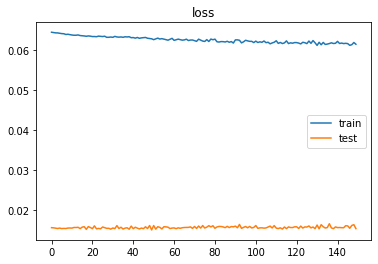

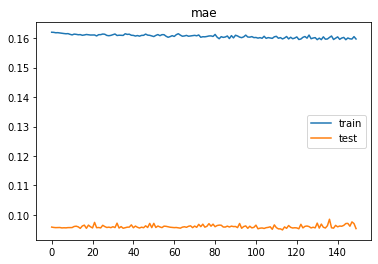

In [34]:
history = model.fit(Xtrain, ytrain, batch_size=32, epochs=150,
                    validation_data=(Xtest, ytest), verbose=1)

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

In [35]:
def plot_multi(y_pred):
    pred_time = y_pred_detrans.shape[0]
    
    ev = metrics.explained_variance_score(test.iloc[-pred_time:,0], y_pred)
    mape_ = metrics.mean_absolute_percentage_error(test.iloc[-pred_time:,0], y_pred)
    mae_ = metrics.mean_absolute_error(test.iloc[-pred_time:,0], y_pred)
    rms = np.sqrt(metrics.mean_squared_error(test.iloc[-pred_time:,0], y_pred))

    print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')
    
    plt.figure()
    plt.plot(train.index, train['count_trips'])
    plt.plot(test.index, test['count_trips'], color='purple', alpha=0.2)
    plt.plot(test.iloc[-pred_time:,:].index, y_pred)
    plt.show()
    
    return

1/1 [==============================] - 0s 441ms/step
[574155.94 575753.75 575927.3  569936.75 545433.56 527139.5  496089.9
 480197.2  463190.5  447809.03 418409.84 394405.44 369225.7  354490.78
 347454.34 329296.8 ]
explained variance: 0.76, mape: 0.73, mae: 112169.56, rms: 127717.17


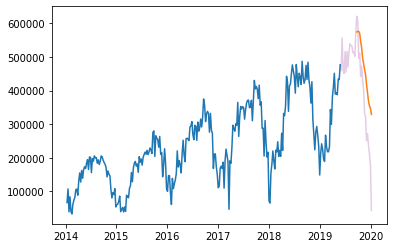

In [36]:
y_pred = model.predict(pred_X)
y_pred = y_pred.reshape(n_output,1)

y_pred_detrans = np.exp(df.iloc[-(n_output+1),2] + y_pred[:,0].cumsum())
print(y_pred_detrans)

plot_multi(y_pred_detrans)

## Train and Predict LSTM

In [37]:
# Use input and output to split the data 
# Choose input and output
n_input = 24
n_output = 32

# Slice dataframe
lstm_train = df.iloc[1:-n_output,:]
lstm_predict = df.iloc[-(n_input+n_output):,:]['log_trips_shift']

# Make train and test set
Xtrain, ytrain = seq_multi_LSTM(lstm_train['log_trips_shift'], n_input, n_output)

# Make predict set
pred_X = lstm_predict.iloc[:n_input].to_numpy().reshape(1,n_input,1)
pred_y = lstm_predict.iloc[-n_output:].to_numpy().reshape(n_output,1)


In [38]:
#-------------------------- Basic multi step output LSTM -----------------------------------------------------
model = lstm_model(Xtrain, n_output, n1=100, n2=50, d_out=0.3)

In [39]:
history = model.fit(Xtrain, ytrain, batch_size=32, epochs=150, verbose=1)

#print_curves(history, 'loss', 'val_loss')
#print_curves(history, 'mae', 'val_mae')

Epoch 1/150
8/8 [==============================] - 7s 433ms/step - loss: 0.0675 - mae: 0.1669
Epoch 2/150
8/8 [==============================] - 3s 420ms/step - loss: 0.0674 - mae: 0.1668
Epoch 3/150
8/8 [==============================] - 3s 417ms/step - loss: 0.0673 - mae: 0.1668
Epoch 4/150
8/8 [==============================] - 3s 410ms/step - loss: 0.0673 - mae: 0.1668
Epoch 5/150
8/8 [==============================] - 3s 422ms/step - loss: 0.0673 - mae: 0.1668
Epoch 6/150
8/8 [==============================] - 3s 419ms/step - loss: 0.0673 - mae: 0.1667
Epoch 7/150
8/8 [==============================] - 3s 432ms/step - loss: 0.0672 - mae: 0.1666
Epoch 8/150
8/8 [==============================] - 4s 453ms/step - loss: 0.0672 - mae: 0.1666
Epoch 9/150
8/8 [==============================] - 4s 448ms/step - loss: 0.0672 - mae: 0.1665
Epoch 10/150
8/8 [==============================] - 3s 434ms/step - loss: 0.0671 - mae: 0.1665
Epoch 11/150
8/8 [==============================] - 4s 449m

KeyboardInterrupt: 

In [ ]:
def plot_multi(y_pred, y_true):
    pred_time = y_pred_detrans.shape[0]
    xx_pred = df.iloc[-pred_time:,:].index 
    
    ev = metrics.explained_variance_score(y_true, y_pred)
    mape_ = metrics.mean_absolute_percentage_error(y_true, y_pred)
    mae_ = metrics.mean_absolute_error(y_true, y_pred)
    rms = np.sqrt(metrics.mean_squared_error(y_true, y_pred))

    print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')
    
    plt.figure()
    plt.plot(train.index, train['count_trips'])
    plt.plot(xx_pred, y_true, color='purple', alpha=0.2)
    plt.plot(xx_pred, y_pred, color='orange')
    plt.show()
    
    return

In [ ]:
y_pred = model.predict(pred_X)
y_pred = y_pred.reshape(n_output,1)

y_pred_detrans = np.exp(df.iloc[-(n_output+1),2] + y_pred[:,0].cumsum())
y_true = np.exp(df.iloc[-(n_output+1),2] + pred_y[:,0].cumsum())

plot_multi(y_pred_detrans, y_true)